# GKP-Based Quantum Error Correction in Photonic Systems
**Series:** GKP-QEC (S03)


## Logical noise model exploration

In S01 and S02 we treated logical noise as one clean knob. That is a good starting point, but real logical noise is not always symmetric. This demo asks a more specific question: what kind of logical noise is acting on the logical qubit?

We keep the circuit fixed and only swap the noise channel. The circuit is always: prepare |+⟩, apply a noise channel, then measure ⟨X⟩. We sweep the same noise strength p for every channel so the curves are comparable.

Why this setup? Because it isolates the noise model as the only difference. Any change you see in the plot is caused by the channel itself, not by a different circuit or a different measurement.

If you want to explore, edit the `channels` list or the `ps` range in the code cell and rerun. That is the simplest way to make the comparison more or less aggressive.


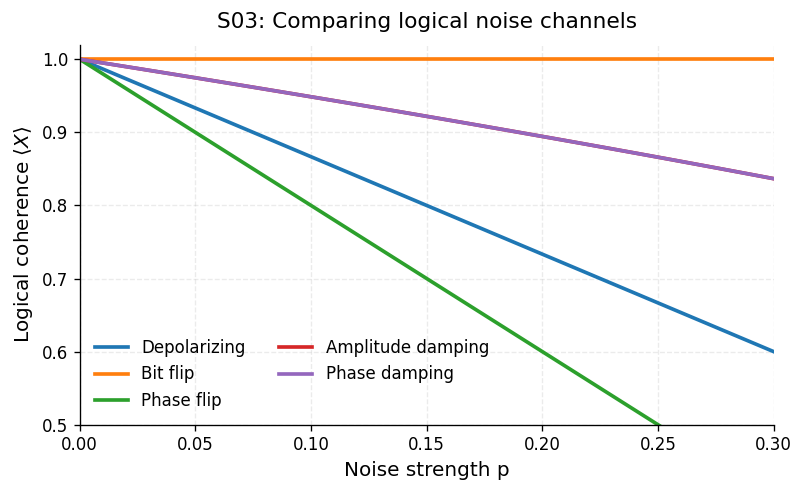

In [1]:
import os

# Ensure a writable Matplotlib cache and a safe backend for notebooks
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("IPYTHONDIR", "/tmp/ipython")

import matplotlib
try:
    from IPython import get_ipython

    if get_ipython() is not None:
        matplotlib.use("module://matplotlib_inline.backend_inline")
except Exception:
    pass

import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml

# Use a mixed-state simulator to model logical noise
dev = qml.device("default.mixed", wires=1)


def apply_plot_style():
    plt.rcParams.update(
        {
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.grid": True,
            "axes.axisbelow": True,
            "grid.alpha": 0.25,
            "grid.linestyle": "--",
            "axes.labelsize": 12,
            "axes.titlesize": 13,
            "axes.titlepad": 10,
            "legend.frameon": False,
            "legend.fontsize": 10,
            "lines.linewidth": 2.2,
            "lines.markersize": 4.5,
        }
    )


apply_plot_style()


@qml.qnode(dev)
def coherence_with_channel(channel, p):
    qml.Hadamard(wires=0)

    if channel == "depolarizing":
        qml.DepolarizingChannel(p, wires=0)
    elif channel == "bit_flip":
        qml.BitFlip(p, wires=0)
    elif channel == "phase_flip":
        qml.PhaseFlip(p, wires=0)
    elif channel == "amplitude_damping":
        qml.AmplitudeDamping(p, wires=0)
    elif channel == "phase_damping":
        qml.PhaseDamping(p, wires=0)
    else:
        raise ValueError(f"Unknown channel: {channel}")

    return qml.expval(qml.PauliX(0))


channels = [
    ("Depolarizing", "depolarizing"),
    ("Bit flip", "bit_flip"),
    ("Phase flip", "phase_flip"),
    ("Amplitude damping", "amplitude_damping"),
    ("Phase damping", "phase_damping"),
]

ps = np.linspace(0.0, 0.30, 61)

fig, ax = plt.subplots(figsize=(6.8, 4.2))
for label, name in channels:
    coh = np.array([coherence_with_channel(name, p) for p in ps])
    ax.plot(ps, coh, label=label)

ax.set_xlabel("Noise strength p")
ax.set_ylabel(r"Logical coherence $\langle X \rangle$")
ax.set_title("S03: Comparing logical noise channels")
ax.set_xlim(ps.min(), ps.max())
ax.set_ylim(0.5, 1.02)
ax.legend(ncol=2)
fig.tight_layout()
plt.show()


### What we're measuring and why

We prepare |+⟩ because it is maximally coherent in the X basis. Measuring ⟨X⟩ directly reports how much of that phase coherence is left after noise.

Phase-type errors (phase flip, phase damping) attack that coherence directly, so their curves drop quickly. Bit-flip noise flips |0⟩ and |1⟩ but does not immediately erase X-basis coherence, so it can look gentler in this specific measurement. Amplitude damping has its own signature because it pushes population toward |0⟩ while also reducing coherence.

The key point is that the measurement choice matters. The same physical device can look "more" or "less" noisy depending on which logical observable you use to probe it.


### What to take away

The curves do not match, and that is the lesson. Different logical error models degrade coherence in different ways, even when they are given the same noise strength parameter.

If you are trying to model a hardware stack at the logical layer, this plot is a reminder to be precise about the channel you choose. "Logical noise" is not one thing. It is a family of models, and each one predicts a different coherence decay.

A practical way to use this demo is to treat the curve shapes as fingerprints. If your measured coherence drops quickly in the X basis, phase-type noise is a likely culprit. If it decays more slowly, bit-flip-like noise may dominate. The goal is not to fit perfectly here, but to build intuition about how channel choice changes the story.
